# Energy Load Profile Classification with 1D CNN

The model uses 24-hour profiles (`h00`–`h23`) without Pearson correlation.

`pip install -r requirements.txt`

## 0. Setup

In [1]:
from pathlib import Path
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader

In [2]:
from src.torch_cnn_1d import CLASS_NAMES
from src.torch_cnn_1d.data import HourWindowDataset, fit_normalization, load_profiles
from src.torch_cnn_1d.model import LoadProfileCNN1D
from src.torch_cnn_1d.plots import plot_architecture, plot_profile_preview, plot_test_examples
from src.torch_cnn_1d.artifacts import save_run
from src.torch_cnn_2d.splits import class_counts, split_profiles
from src.torch_cnn_2d.engine import evaluate, predict_one, summarize_test, train_model
from src.torch_cnn_2d.plots import (
    plot_confusion_matrix, plot_learning_curves
)

In [3]:
SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 30
PATIENCE = 6
LEARNING_RATE = 1e-3
DATA_DIR = Path("dataset/load_energy_3class_daily")
OUTPUT_DIR = Path("outputs/cnn_1d_load_profile_24h")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("PyTorch:", torch.__version__, "| Device:", device)

PyTorch: 2.14.1 | Device: mps


## 1. Load data

In [5]:
records, hourly = load_profiles(DATA_DIR)
print("Total profiles:", len(records))
for name, count in class_counts(records).items():
    print(f"{name:14s}: {count}")
print("Hours per profile:", len(hourly[records[0]["sample_id"]]))

Total profiles: 6720
low activity  : 967
typical       : 4709
peak dominant : 1044
Hours per profile: 24


## 2. Preview the data

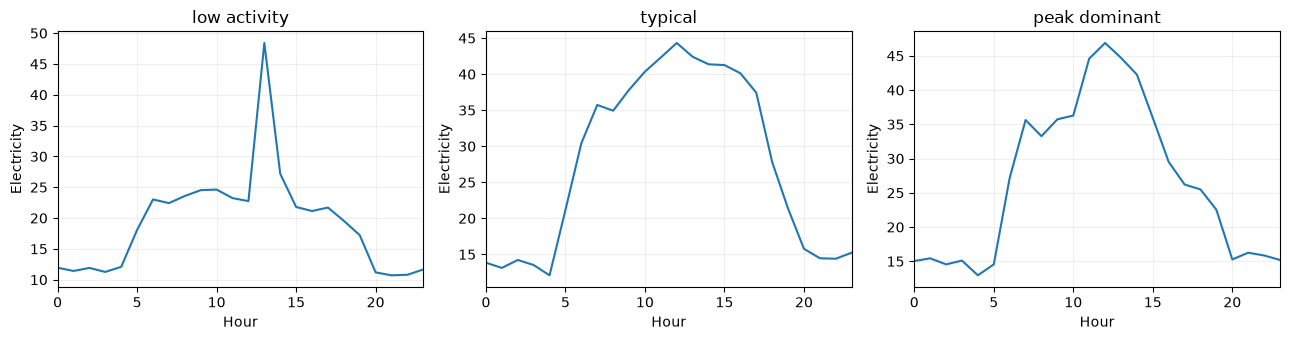

In [6]:
fig = plot_profile_preview(records, hourly, OUTPUT_DIR / "profile_preview.png")
plt.show()

## 3. Split the data

Stratified by profile: 60% training, 20% validation, 20% test. Normalization uses training data only. Profiles from the same building may appear in different splits.

In [7]:
train_rows, val_rows, test_rows = split_profiles(records, seed=SEED)
for name, rows in [("Train", train_rows), ("Validation", val_rows), ("Test", test_rows)]:
    print(f"{name:10s} {len(rows):4d} profiles | {class_counts(rows)}")

normalization = fit_normalization(train_rows, hourly)
train_dataset = HourWindowDataset(train_rows, hourly, normalization)
val_dataset = HourWindowDataset(val_rows, hourly, normalization)
test_dataset = HourWindowDataset(test_rows, hourly, normalization)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample, label = train_dataset[0]
print("CNN input shape:", tuple(sample.shape), "| Label:", CLASS_NAMES[int(label)])

Train      4031 profiles | {'low activity': 580, 'typical': 2825, 'peak dominant': 626}
Validation 1344 profiles | {'low activity': 193, 'typical': 942, 'peak dominant': 209}
Test       1345 profiles | {'low activity': 194, 'typical': 942, 'peak dominant': 209}
CNN input shape: (1, 24) | Label: typical


## 4. Build the architecture

In [ ]:
model = LoadProfileCNN1D().to(device)

counts = np.bincount([int(row["class_id"]) for row in train_rows], minlength=3)

class_weights = len(train_rows) / (len(CLASS_NAMES) * counts)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32, device=device)
)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

print(model)
print("Parameters:", sum(parameter.numel() for parameter in model.parameters()))

LoadProfileCNN1D(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=192, out_features=64, bias=True)
    (2): ReLU

## 5. Preview the architecture with VisualTorch

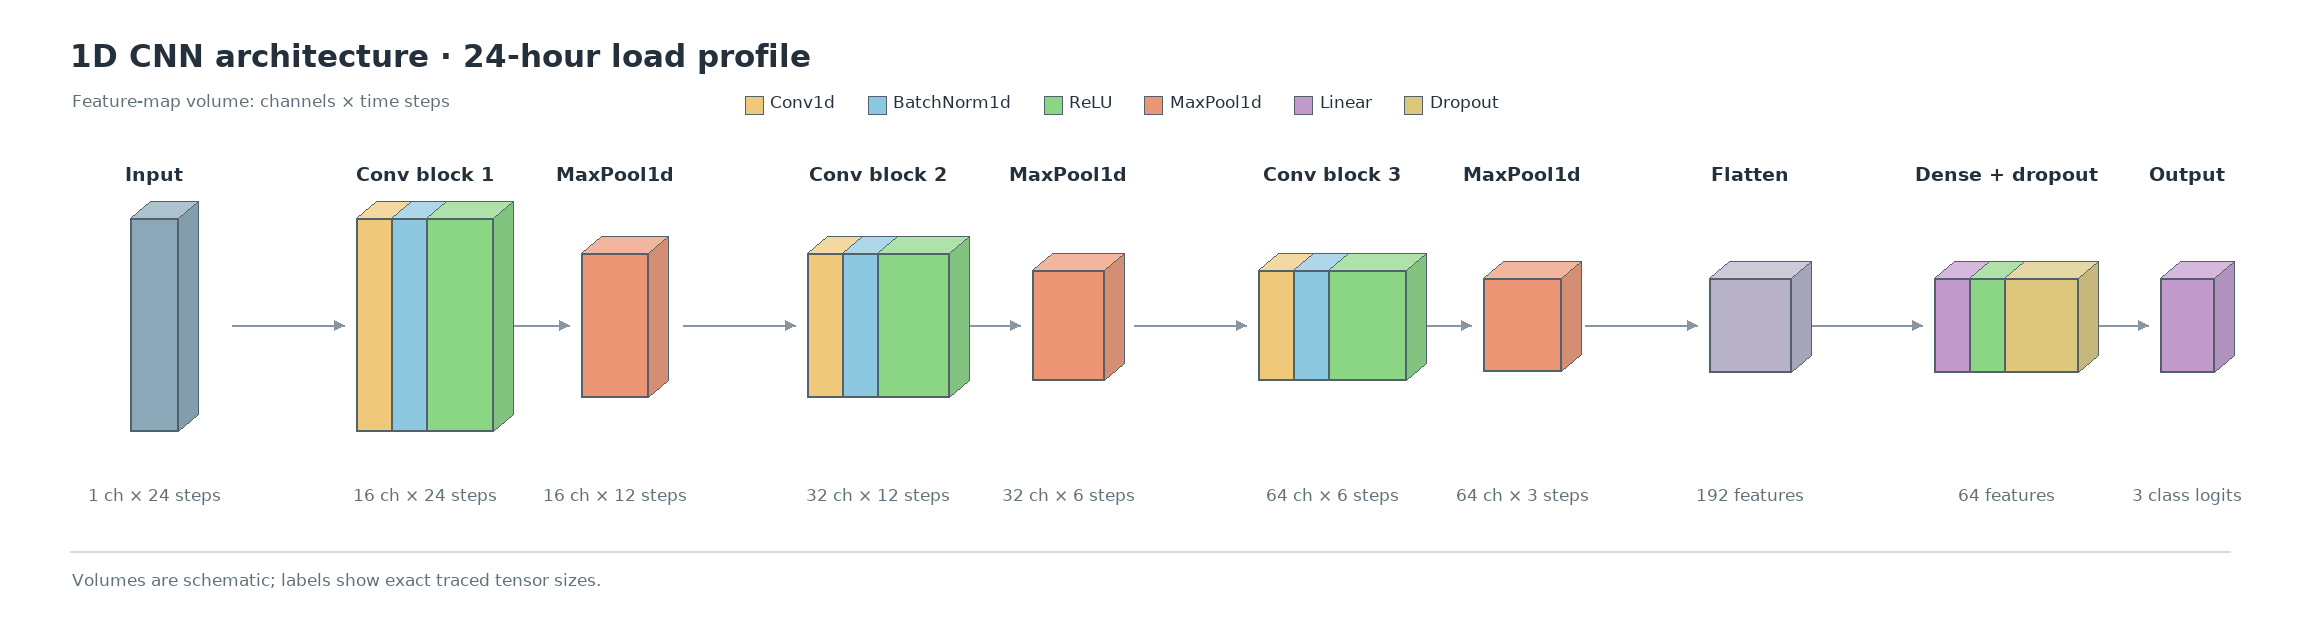

In [9]:
architecture_image = plot_architecture(model, (1, 24), OUTPUT_DIR / "architecture.png")
display(architecture_image)

## 6. Train the model

The best epoch is selected using validation macro-F1.

In [12]:
%%time
print("Training ...")
history, best_epoch, best_val_f1 = train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    device,
    max_epochs=MAX_EPOCHS, 
    patience=PATIENCE
)
print("Best epoch:", best_epoch, "| Validation macro-F1:", round(best_val_f1, 3))

Training ...
Epoch 01 | train loss 0.2121 | val loss 0.3269 | val macro-F1 0.862
Epoch 02 | train loss 0.2272 | val loss 0.3287 | val macro-F1 0.869
Epoch 03 | train loss 0.2076 | val loss 0.3639 | val macro-F1 0.851
Epoch 04 | train loss 0.1953 | val loss 0.3272 | val macro-F1 0.861
Epoch 05 | train loss 0.1973 | val loss 0.3782 | val macro-F1 0.843
Epoch 06 | train loss 0.1960 | val loss 0.3568 | val macro-F1 0.856
Epoch 07 | train loss 0.1949 | val loss 0.3777 | val macro-F1 0.865
Epoch 08 | train loss 0.1810 | val loss 0.3654 | val macro-F1 0.851
Early stopping at epoch 8
Best epoch: 2 | Validation macro-F1: 0.869
CPU times: user 714 ms, sys: 184 ms, total: 898 ms
Wall time: 1.73 s


## 7. Evaluate the model

In [ ]:
test_result = evaluate(model, test_loader, criterion, device)

metrics = summarize_test(test_result, train_rows)

In [ ]:
print(f"Test loss: {metrics['test_loss']:.4f}")
print(f"Test accuracy: {metrics['test_accuracy']:.3f}")
print(f"Test macro-F1: {metrics['test_macro_f1']:.3f}")
print(f"Majority-class baseline macro-F1: {metrics['majority_baseline_macro_f1']:.3f}")
print("\nPer-class scores:")


for name in CLASS_NAMES:
    score = metrics["per_class"][name]
    print(f"{name:14s} precision={score['precision']:.3f} "
          f"recall={score['recall']:.3f} F1={score['f1']:.3f} n={score['support']}")

Test loss: 0.3800
Test accuracy: 0.912
Test macro-F1: 0.869
Majority-class baseline macro-F1: 0.275

Per-class scores:
low activity   precision=0.693 recall=0.918 F1=0.789 n=194
typical        precision=0.980 recall=0.926 F1=0.952 n=942
peak dominant  precision=0.889 recall=0.842 F1=0.865 n=209


## 8. Test predictions visually

Green titles are correct predictions; red titles are errors.

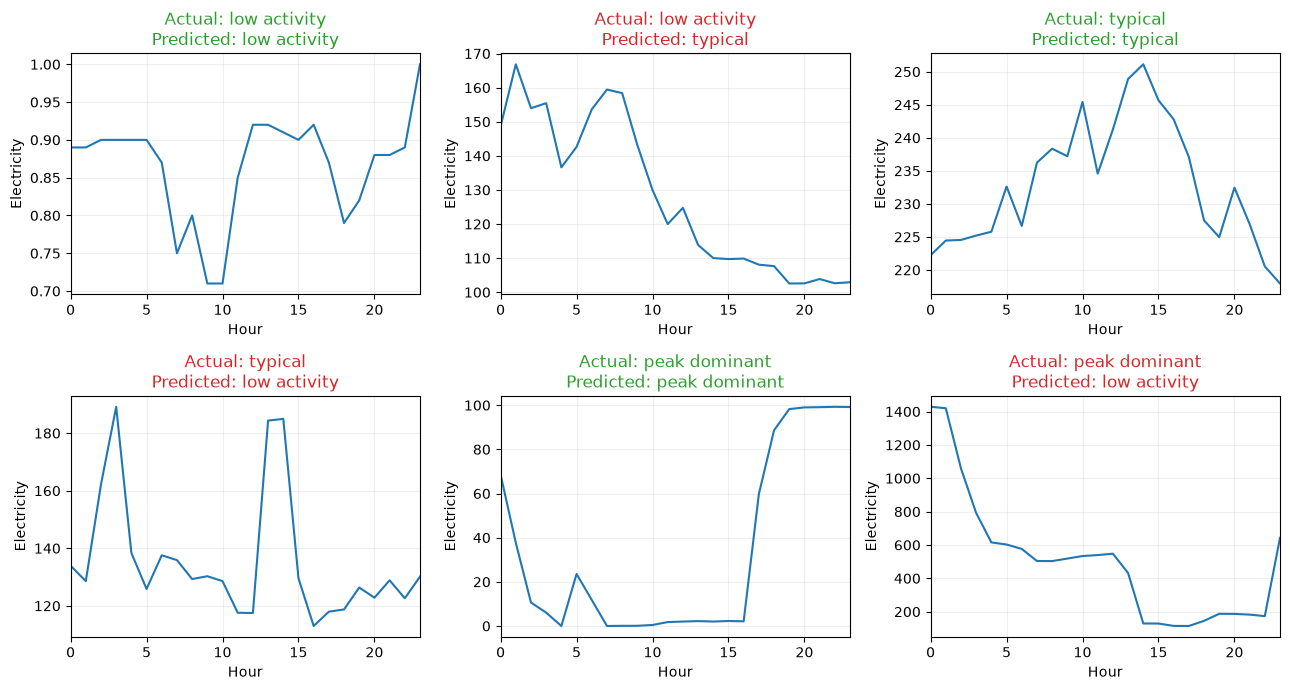

In [13]:
fig = plot_test_examples(
    test_rows, hourly, test_result["predicted"], OUTPUT_DIR / "test_examples.png"
)
plt.show()

In [14]:
actual, predicted, probabilities = predict_one(
    model, test_dataset, index=0, device=device
)
print("Test sample:", test_rows[0]["sample_id"])
print("Actual:", CLASS_NAMES[actual], "| Predicted:", CLASS_NAMES[predicted])
print("Probabilities:", dict(zip(CLASS_NAMES, probabilities.round(3))))

Test sample: BN024_2019-11-18
Actual: typical | Predicted: typical
Probabilities: {'low activity': np.float32(0.002), 'typical': np.float32(0.998), 'peak dominant': np.float32(0.0)}


## 9. Compare performance

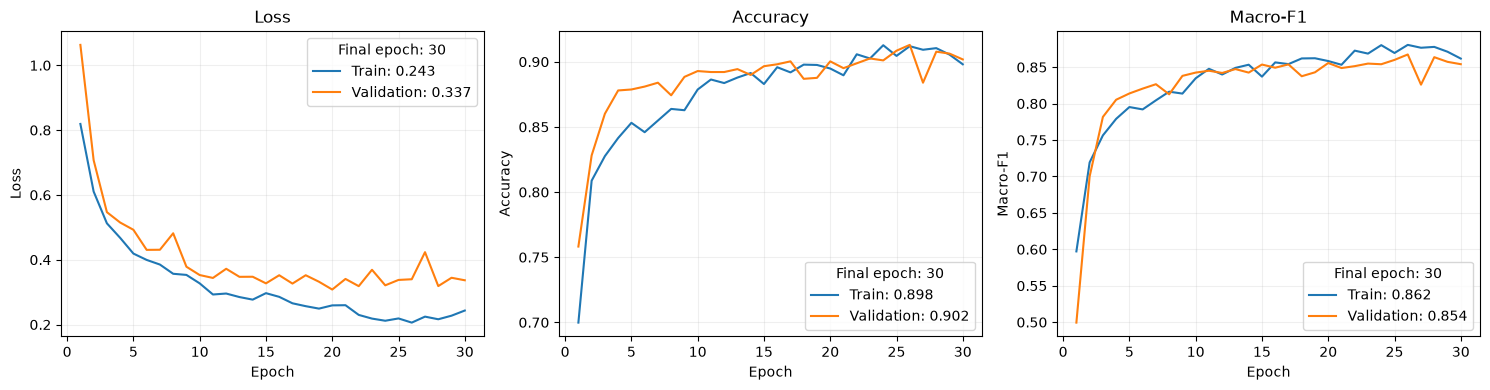

In [15]:
fig = plot_learning_curves(history, OUTPUT_DIR / "training_curves.png")
plt.show()

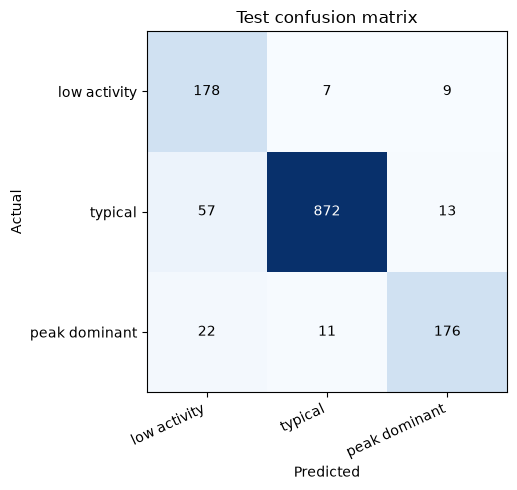

In [16]:
fig = plot_confusion_matrix(test_result["matrix"], OUTPUT_DIR / "confusion_matrix.png")
plt.show()

## 10. Save the results

In [17]:
report = save_run(
    OUTPUT_DIR, model, history, metrics,
    (train_rows, val_rows, test_rows), normalization, SEED, best_epoch
)
print("Saved to:", OUTPUT_DIR.resolve())
print("Test accuracy:", round(report["test_accuracy"], 3),
      "| Test macro-F1:", round(report["test_macro_f1"], 3))

Saved to: /Users/zendi.iklima/Documents/UTP/My Lectures/Intelligence System/Scripts/outputs/cnn_1d_load_profile_24h
Test accuracy: 0.912 | Test macro-F1: 0.869
